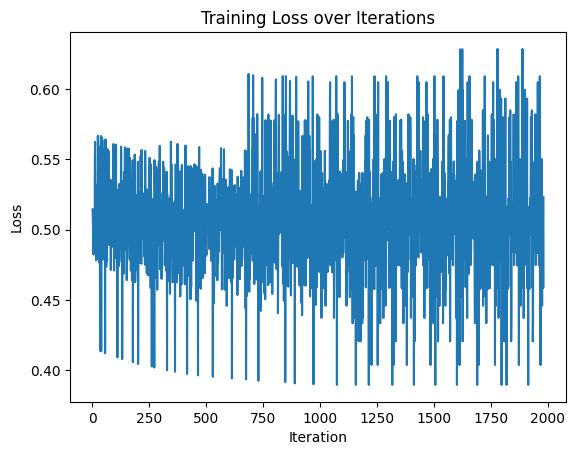

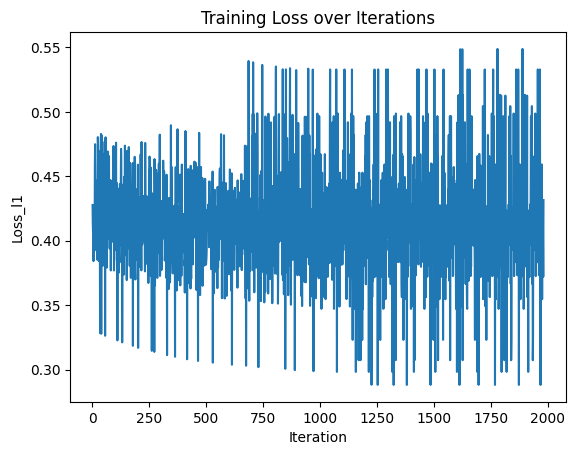

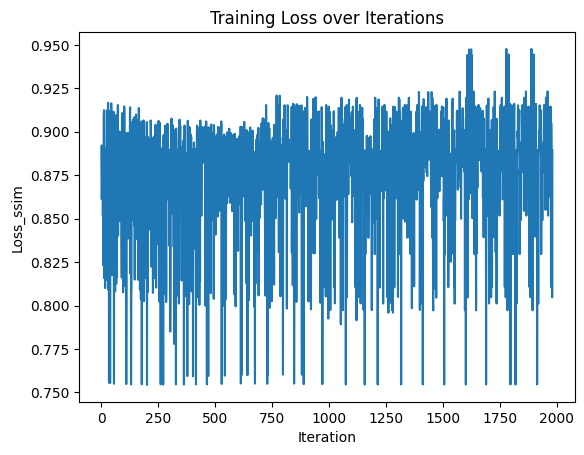

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV you just generated
df1 = pd.read_csv('loss.csv', names=['iteration', 'loss'])

plt.figure()
plt.plot(df1['iteration'], df1['loss'])
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')

plt.savefig('loss_plot.png', dpi=300, bbox_inches='tight')

plt.show()

# Read the CSV you just generated
df2 = pd.read_csv('loss_l1.csv', names=['iteration', 'loss'])

plt.figure()
plt.plot(df2['iteration'], df2['loss'])
plt.xlabel('Iteration')
plt.ylabel('Loss_l1')
plt.title('Training Loss over Iterations')

plt.savefig('loss_l1_plot.png', dpi=300, bbox_inches='tight')

# Read the CSV you just generated
df3 = pd.read_csv('loss_ssim.csv', names=['iteration', 'loss'])

plt.figure()
plt.plot(df3['iteration'], df3['loss'])
plt.xlabel('Iteration')
plt.ylabel('Loss_ssim')
plt.title('Training Loss over Iterations')

plt.savefig('loss_ssim_plot.png', dpi=300, bbox_inches='tight')


In [ ]:
import numpy as np
import open3d as o3d

# === Configuration ===
BASE = "/home/dimitris/Photo-SLAM"
OUT_IMG = "voxel_debug.png"
MAX_CUBES = 5500  # limit cubes for visibility

# === Load data ===
pts     = np.load(f"{BASE}/debug_pts.npy")          # N×3
cols    = np.load(f"{BASE}/debug_cols.npy")         # N×3 (in [0,1])
centers = np.load(f"{BASE}/debug_vox_centers.npy")  # M×3
sizes   = np.load(f"{BASE}/debug_vox_size.npy")     # M
# grid_xyz = np.load(f"{BASE}/debug_grid_xyz.npy")  # [numGP, 3]

# === Point Cloud ===
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pts)
pcd.colors = o3d.utility.Vector3dVector(cols)

# grid_pcd = o3d.geometry.PointCloud()
# grid_pcd.points = o3d.utility.Vector3dVector(grid_xyz)
# # colour the grid bright white
# grid_pcd.paint_uniform_color((1.0, 0.0, 0.0))  # red
# grid_pcd.points = grid_pcd.points  # to be safe

# === Voxel Grid as Wireframes ===
M = len(centers)
sel = np.random.choice(M, min(M, MAX_CUBES), replace=False)
sel_centers = centers[sel]
sel_sizes   = sizes[sel]

all_corners = []
all_edges   = []
for i, (c, s) in enumerate(zip(sel_centers, sel_sizes)):
    e = s * 0.5
    x, y, z = c
    # 8 corners of the cube
    corners = np.array([
        [x-e, y-e, z-e],
        [x-e, y-e, z+e],
        [x-e, y+e, z-e],
        [x-e, y+e, z+e],
        [x+e, y-e, z-e],
        [x+e, y-e, z+e],
        [x+e, y+e, z-e],
        [x+e, y+e, z+e],
    ])
    base = i * 8
    edges = [
        (0,1),(0,2),(0,4),(3,1),(3,2),(3,7),
        (5,1),(5,4),(5,7),(6,2),(6,4),(6,7)
    ]
    all_corners.append(corners)
    for a, b in edges:
        all_edges.append([base + a, base + b])

all_corners = np.vstack(all_corners)
all_edges   = np.array(all_edges)

line_set = o3d.geometry.LineSet()
line_set.points = o3d.utility.Vector3dVector(all_corners)
line_set.lines  = o3d.utility.Vector2iVector(all_edges)
# color edges
line_set.colors = o3d.utility.Vector3dVector([[1.0, 0.4, 0.0]] * len(all_edges))

# === Visualization ===
o3d.visualization.draw_geometries(
    [pcd, line_set],
    # [pcd],
    window_name="PointCloud + Voxel Grid",
    width=1024, height=768
)
# o3d.visualization.draw_geometries([grid_pcd],
#                                   window_name="PointCloud + Grid Points",
#                                   width=1024, height=768)

# center = grid_xyz.mean(axis=0)
# o3d.visualization.draw_geometries(
#     # [pcd, grid_pcd, line_set],
#     # [line_set],
#     [pcd, line_set],
#     zoom=0.6,
#     front=[0,0,-1],
#     lookat=center,
#     up=[0,-1,0]
# )

# # === Off‐screen Render + Screenshot ===
# vis = o3d.visualization.Visualizer()
# vis.create_window(width=1024, height=768, visible=False)

# # add geometries
# vis.add_geometry(pcd)
# # vis.add_geometry(line_set)

# # tweak render options
# opt = vis.get_render_option()
# opt.background_color = np.asarray([0,0,0])  # black background
# opt.point_size       = 2                    # make points larger

# # set camera
# ctr = vis.get_view_control()
# center = grid_xyz.mean(axis=0)
# ctr.set_front([0,0,-1])
# ctr.set_up   ([0,-1,0])
# ctr.set_lookat(center)
# ctr.set_zoom(0.6)

# # render & capture
# vis.poll_events()
# vis.update_renderer()
# vis.capture_screen_image(OUT_IMG, do_render=True)
# vis.destroy_window()

# print(f"Saved screenshot to {OUT_IMG}")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
import numpy as np, cv2
from pathlib import Path

# user picks:
kf = 0
iteration = 533  
BASE_ROOT = Path("/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk")
# build the per‐KF directory
kf_dir = BASE_ROOT / f"kf{kf:04d}"
if not kf_dir.is_dir():
    raise FileNotFoundError(f"{kf_dir} does not exist")
# helper to zero‐pad iteration
it6 = f"{iteration:06d}"
# 1) load the GT image, K, w2c, and the PCD
img_path  = kf_dir / f"gt_kf{kf:04d}_iter{it6}.png"
K_path    = kf_dir / f"K_kf{kf:04d}_iter{it6}.npy"
w2c_path  = kf_dir / f"w2c_kf{kf:04d}_iter{it6}.npy"

# load them
img   = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
K     = np.load(K_path)
w2c   = np.load(w2c_path)
pts      = np.load("/home/dimitris/Photo-SLAM/debug_pts.npy")
cols     = np.load("/home/dimitris/Photo-SLAM/debug_cols.npy")

# 2) decompose w2c
if w2c.shape == (4,4):
    R = w2c[:3,:3]
    t = w2c[:3, 3:]
else:
    R = w2c[:3,:3]
    t = w2c[:3, 3:4]

print(f"K = {K}")
print(f"R = {R}")
print(f"t = {t}")

rvec, _   = cv2.Rodrigues(R)
tvec      = t
# project
img_pts, _ = cv2.projectPoints(pts, rvec, tvec, K, distCoeffs=None)
img_pts = img_pts.reshape(-1,2)

# draw
for (u,v), col in zip(img_pts, cols):
    u, v = int(round(u)), int(round(v))
    if 0 <= u < img.shape[1] and 0 <= v < img.shape[0]:
        bgr = tuple((col*255).astype(np.uint8).tolist())
        cv2.circle(img, (u,v), 2, bgr, -1)

cv2.imshow(f"PCD on KF{kf}", img)
cv2.waitKey(0)
# cv2.destroyAllWindows()


K = [[517.3064    0.      318.64304]
 [  0.      516.46924 255.314  ]
 [  0.        0.        1.     ]]
R = [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
t = [[0.]
 [0.]
 [0.]]


233

: 

In [9]:

import os
import glob
import cv2
from IPython.display import HTML
from base64 import b64encode

# Path to your folder containing images
image_folder = "/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0"
# image_folder = "/home/dimitris/Photo-SLAM_original/results/tum_mono_/rgbd_dataset_freiburg1_desk/extrema/kf0"

# Glob pattern (change to *.png if needed)
# pattern = "*.jpg"
pattern = "*.png"

# Output video filename
output_video = "timelapse.mp4"
# output_video = "timelapse_original.mp4"

speed_factor = 0.5
# Frames per second
fps = 10
effective_fps = fps * speed_factor

# find all matching files
paths = glob.glob(os.path.join(image_folder, pattern))

# sort by numeric suffix (assumes filenames like prefix_INDEX.jpg)
def sort_key(path):
    name = os.path.basename(path)
    base, _ = os.path.splitext(name)
    # take the last underscore component as integer
    try:
        idx = int(base.split("_")[-1])
    except:
        idx = base
    return idx

paths = sorted(paths, key=sort_key)
print(f"Found {len(paths)} images, first few:", paths[:5])

# read first frame to get size
frame = cv2.imread(paths[0])
h, w, _ = frame.shape

# define the codec and create VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # or 'XVID'
video_writer = cv2.VideoWriter(output_video, fourcc, effective_fps, (w, h))

# iterate and write frames
for p in paths:
    img = cv2.imread(p)
    video_writer.write(img)

video_writer.release()
print("Video saved to", output_video)

# display the resulting video inline (Jupyter only)
mp4 = open(output_video,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f"""
<video width=640 controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")

Found 22 images, first few: ['/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0/best_masked_iter000023_img000.png', '/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0/best_masked_iter000037_img000.png', '/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0/best_masked_iter000062_img000.png', '/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0/best_masked_iter000090_img000.png', '/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0/best_masked_iter000112_img000.png']
Video saved to timelapse.mp4


In [2]:
from PIL import Image
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# load once
gt     = Image.open("/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/heatmaps/kf0/kf0000_iter000016.png")
render = Image.open("/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/heatmaps/kf0/kf0000_iter000020_gt.png")     # or your heatmap file

def blend(alpha: float):
    plt.figure(figsize=(6,6))
    plt.imshow(gt)
    plt.imshow(render, alpha=alpha)
    plt.axis("off")
    plt.title(f"alpha = {alpha:.2f}")
    plt.show()

interact(blend,
         alpha=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5,
                           description="opacity"))


interactive(children=(FloatSlider(value=0.5, description='opacity', max=1.0, step=0.01), Output()), _dom_class…

<function __main__.blend(alpha: float)>